### Housing price prediction - regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Zadanie 8
# a)
california_df = pd.read_csv("housing(in).csv")

# b)
print(california_df.info())
print(california_df.describe())

# c)
print(california_df["ocean_proximity"].unique())
print(california_df["ocean_proximity"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952     

<Axes: xlabel='ocean_proximity', ylabel='count'>

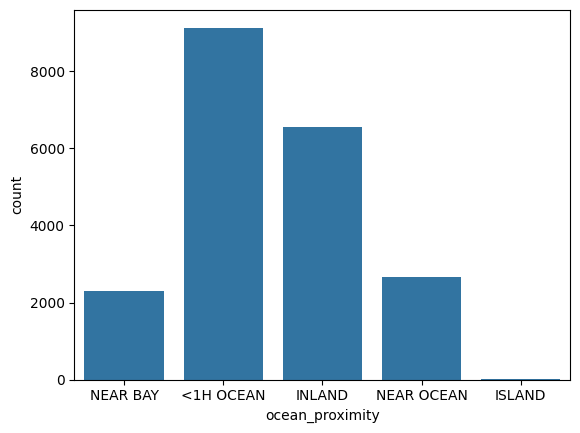

In [3]:
# Zadanie 9
# a)
sns.countplot(data=california_df, x="ocean_proximity")


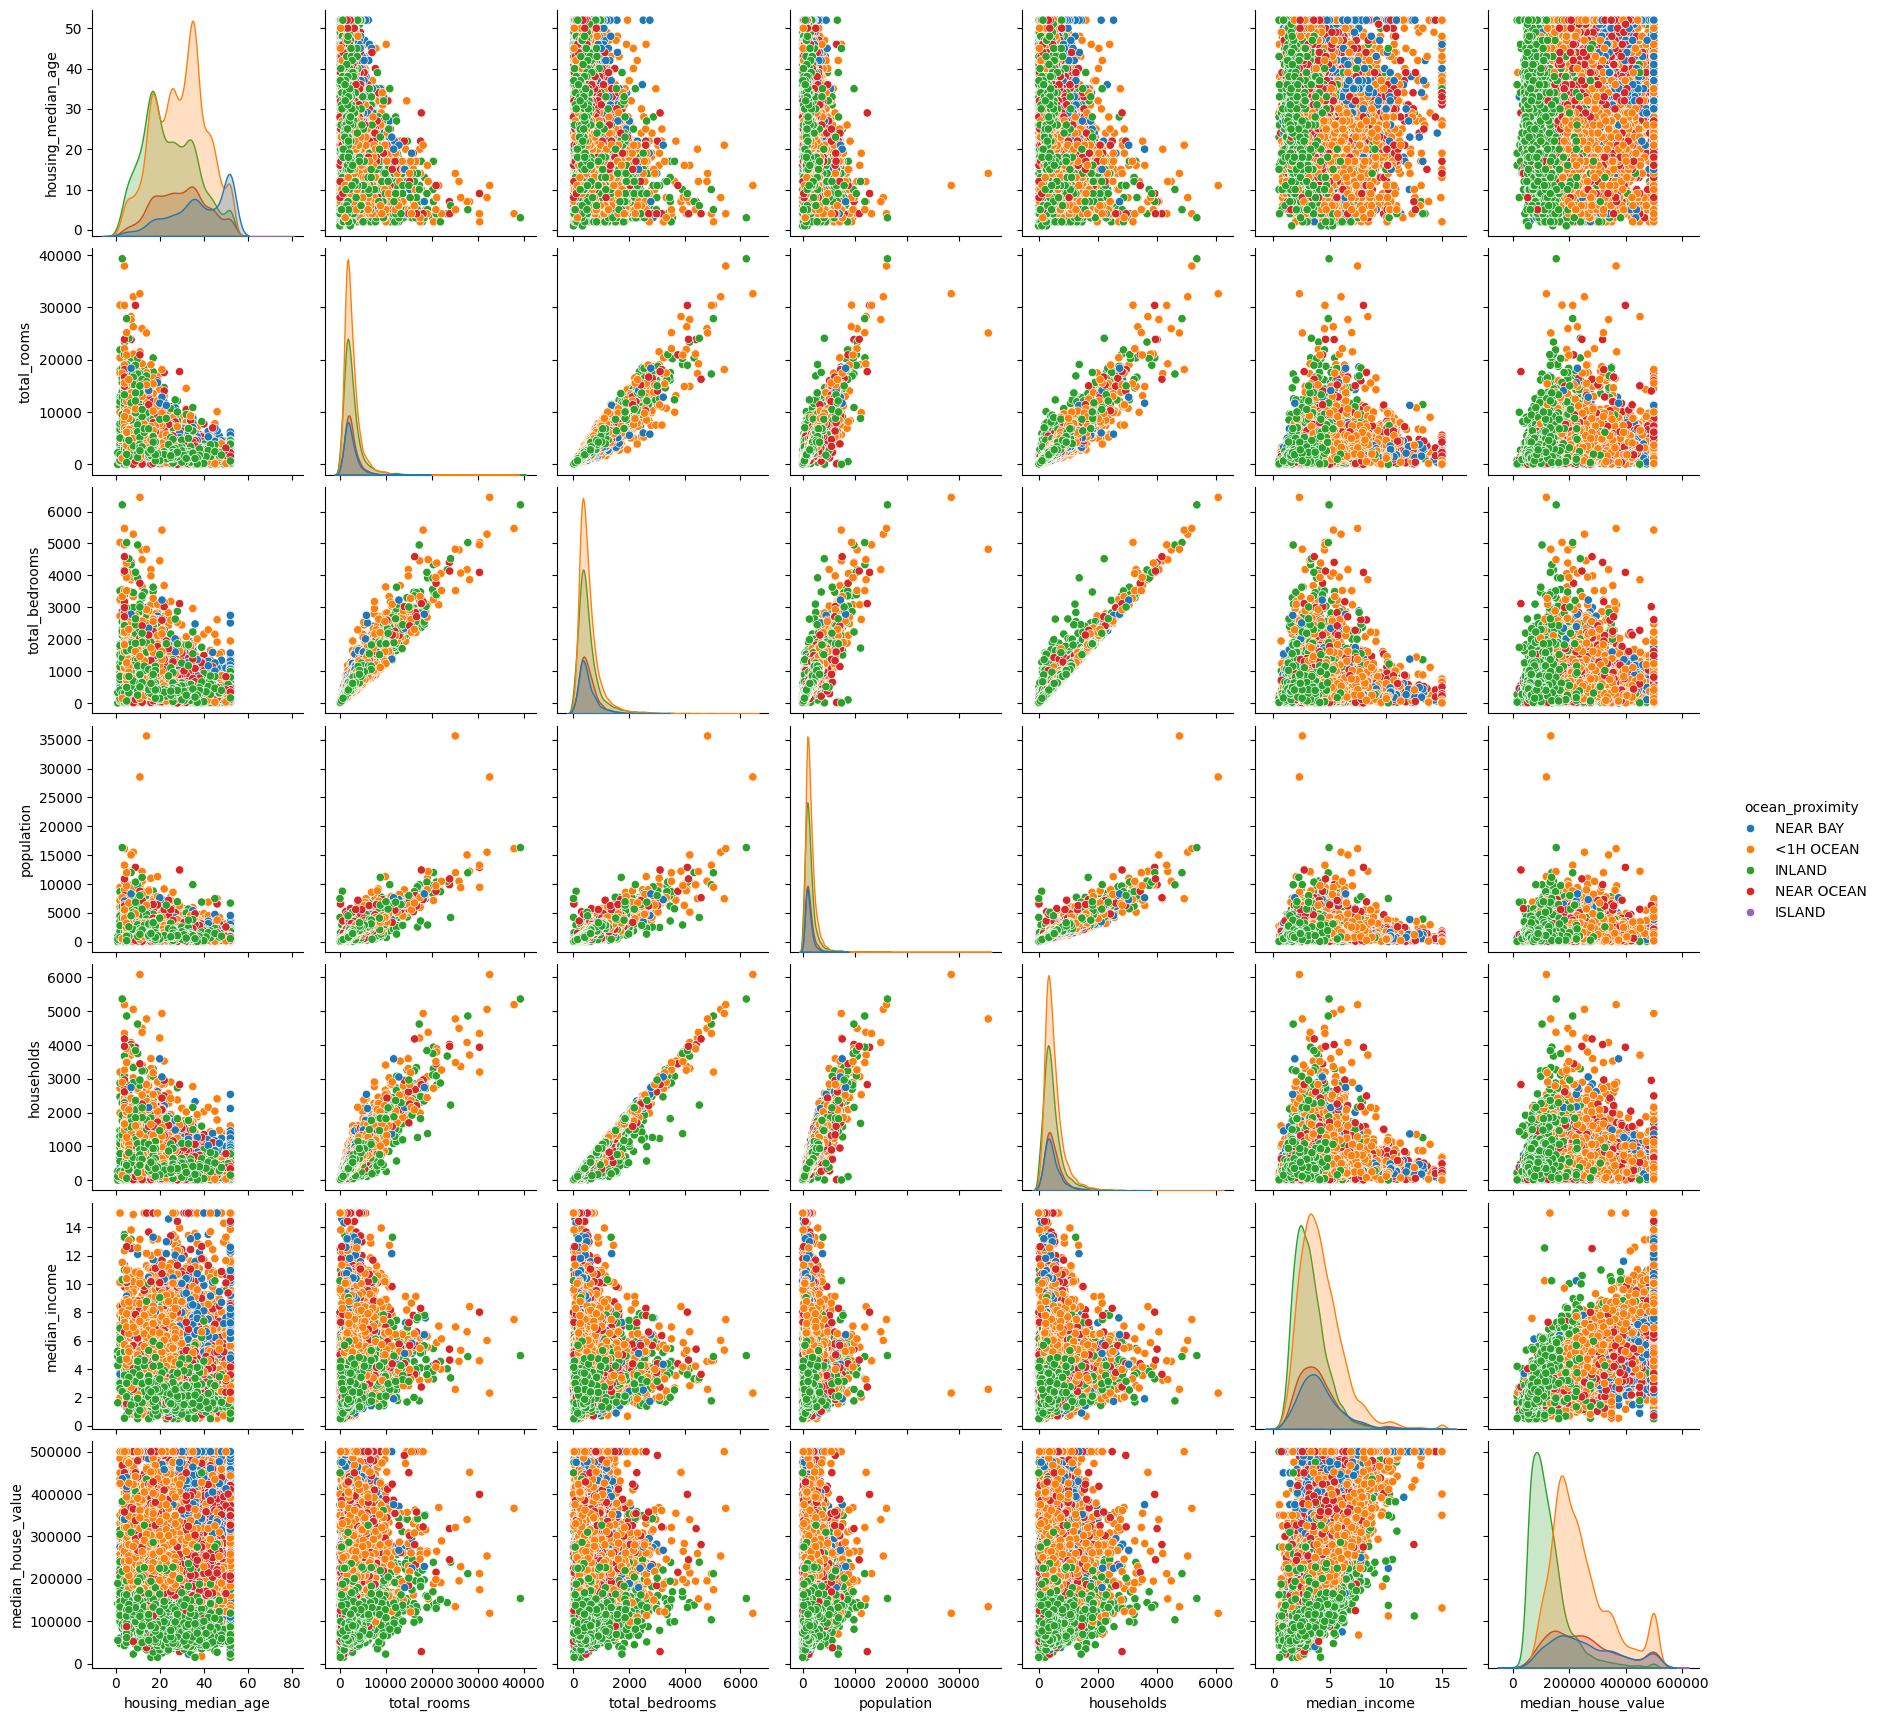

In [4]:
# b)
pair_plot_data = california_df.drop(columns=["longitude", "latitude"])
sns.pairplot(data=pair_plot_data, hue="ocean_proximity")

<Axes: xlabel='total_rooms', ylabel='Count'>

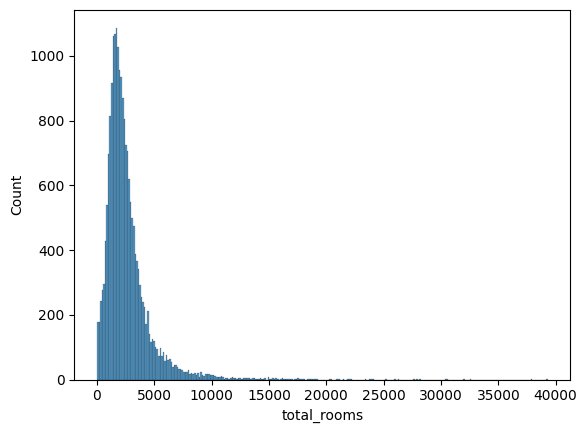

In [5]:

# c)
sns.histplot(california_df["total_rooms"]) 

<Axes: ylabel='total_rooms'>

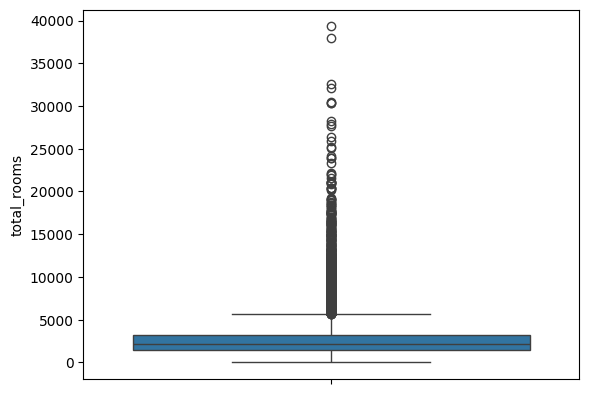

In [6]:

sns.boxplot(california_df["total_rooms"])# Outliers above ~ 33k

<Axes: xlabel='total_bedrooms', ylabel='Count'>

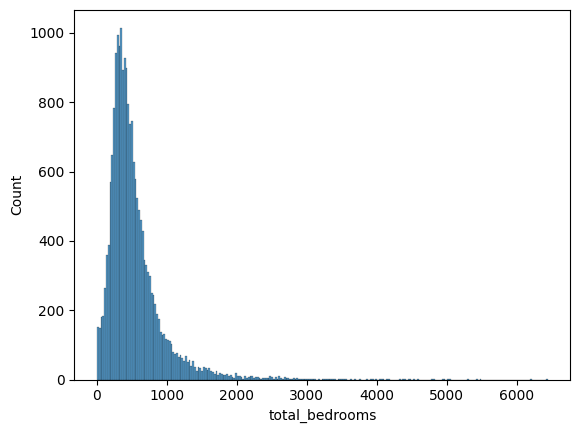

In [7]:
sns.histplot(california_df["total_bedrooms"]) 

<Axes: ylabel='total_bedrooms'>

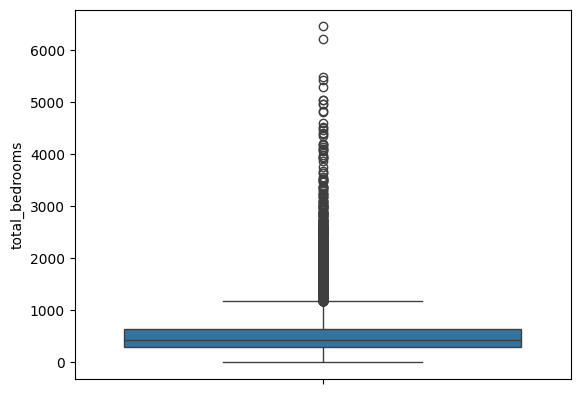

In [8]:
sns.boxplot(california_df["total_bedrooms"]) # Outliers around ~ 5500

<Axes: xlabel='population', ylabel='Count'>

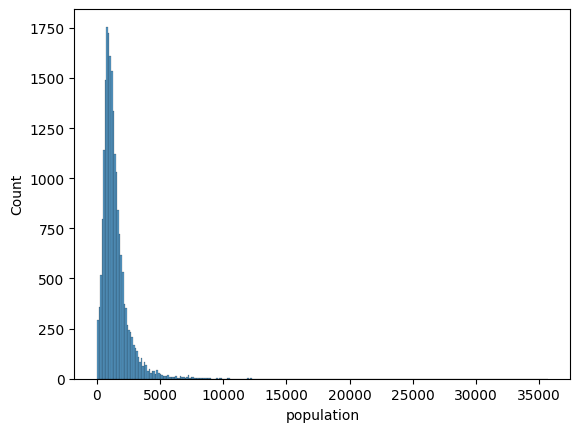

In [9]:
sns.histplot(california_df["population"]) 

<Axes: ylabel='population'>

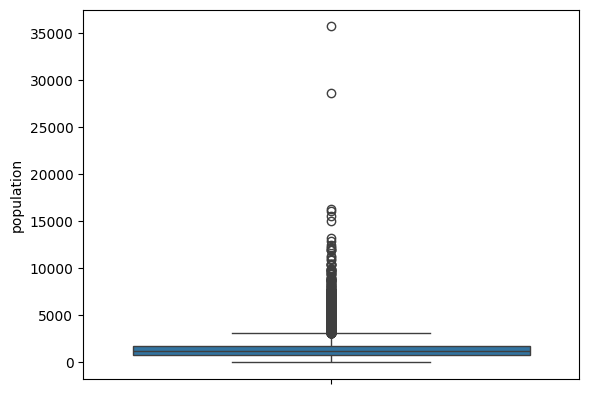

In [10]:
sns.boxplot(california_df["population"]) # Outliers after ~ 17k

<Axes: xlabel='households', ylabel='Count'>

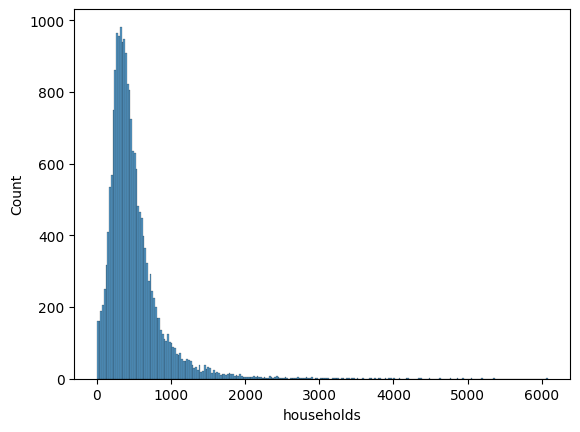

In [11]:
sns.histplot(california_df["households"]) 

<Axes: ylabel='households'>

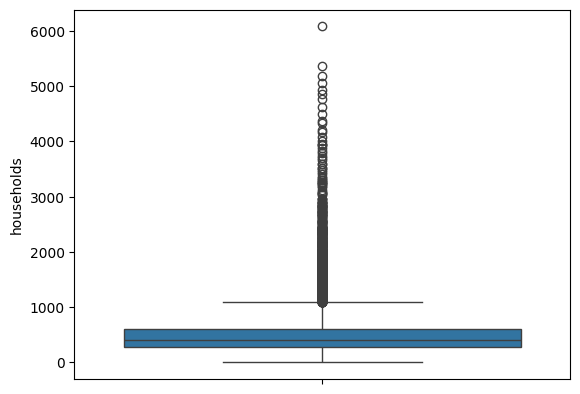

In [12]:
sns.boxplot(california_df["households"]) # Outliers ~ 6k

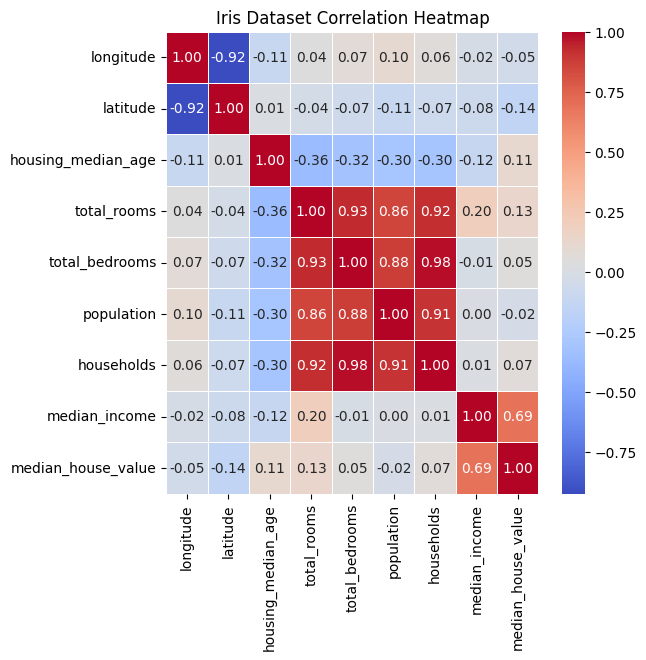

In [13]:
# d) 
numerical_data_df = california_df.select_dtypes("number")
corr_matrix = numerical_data_df.corr(method="pearson")

plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Iris Dataset Correlation Heatmap")
plt.show()


In [14]:
# Zadanie 10
# a)
threshold = 0.8
total_bedrooms_corr = corr_matrix["total_bedrooms"]
top_bedrooms_corr = total_bedrooms_corr.loc[
    (total_bedrooms_corr > threshold) & 
    (total_bedrooms_corr != 1.0)
]
print(top_bedrooms_corr)

# b)
total_bedrooms_col = california_df["total_bedrooms"]
rows_NA = total_bedrooms_col.loc[total_bedrooms_col.isnull()].index
print(rows_NA)

total_rooms    0.930380
population     0.877747
households     0.979728
Name: total_bedrooms, dtype: float64
Index([  290,   341,   538,   563,   696,   738,  1097,  1350,  1456,  1493,
       ...
       19932, 19959, 20046, 20069, 20125, 20267, 20268, 20372, 20460, 20484],
      dtype='int64', length=207)


In [ ]:
# c)
df_dropped_nulls_total_bedrooms = california_df.drop(labels=rows_NA, axis=0)
X_OK = df_dropped_nulls_total_bedrooms[top_bedrooms_corr.index]

# d)
y_OK = df_dropped_nulls_total_bedrooms["total_bedrooms"]

# e)
linear_reg = LinearRegression()
linear_reg.fit(X=X_OK, y=y_OK)

# f)
X_NA = california_df.loc[total_bedrooms_col.isnull()][top_bedrooms_corr.index]

# g)
y_bedrooms_preds = linear_reg.predict(X=X_NA)
california_df.loc[rows_NA, "total_bedrooms"] = y_bedrooms_preds
print(f"Verify is there any null in total_bedrooms: {california_df["total_bedrooms"].isnull().value_counts()}")
california_df.describe()

Verify is there any null in total_bedrooms: total_bedrooms
False    20640
Name: count, dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.925294,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.192130,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,295.130310,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000
